<h1><center>Analyse de conversations patient-thérapeute sur la santé mentale</center></h1>

> *La santé mentale est un enjeu majeur de la santé publique. Ce projet vise, dans un premier temps, à exploiter le jeu de données pour comprendre les types de conversations et leur structure, puis à analyser les sentiments des échanges afin de détecter les émotions et états psychologiques des patients. Ensuite, il se concentre sur l'accès et le traitement des conversations, en résumant les échanges et en identifiant les schémas linguistiques récurrents. Enfin, il prévoit le développement d'un système question-réponse, capable d'automatiser les interactions et fournir des réponses.*

---
## ÉTAPE 1 : Exploration du jeu de données et Extraction de sujets

### 1. Importation des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from gensim.models import Word2Vec

# Téléchargement des outils NLTK nécessaires
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords

# Configuration visuelle pour les graphiques
sns.set_theme(style='whitegrid')

[nltk_data] Downloading package punkt to /home/le_v/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /home/le_v/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


### 2. Chargement et Statistiques descriptives
Le jeu de données contient deux colonnes principales : `Context` (les propos du patient) et `Response` (la réponse du thérapeute).
Étant donné qu'il n'y a pas d'identifiants explicites pour les patients et les thérapeutes, nous allons faire une approximation : les textes uniques dans `Context` représenteront les patients uniques, et les textes uniques dans `Response` représenteront les thérapeutes.

In [2]:
# Chargement des données
df = pd.read_csv('train.csv')

# Suppression des valeurs nulles potentielles
df = df.dropna()

print(f"Dimensions du dataset : {df.shape}\n")
display(df.head(3))

Dimensions du dataset : (3508, 2)



,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...


--- TABLEAU STATISTIQUE RÉCAPITULATIF ---
Nombre total d'échanges : 3508
Nombre de patients (Contextes uniques) : 995
Nombre de thérapeutes (Réponses uniques) : 2479
Moyenne d'échanges par thérapeute : 1.42


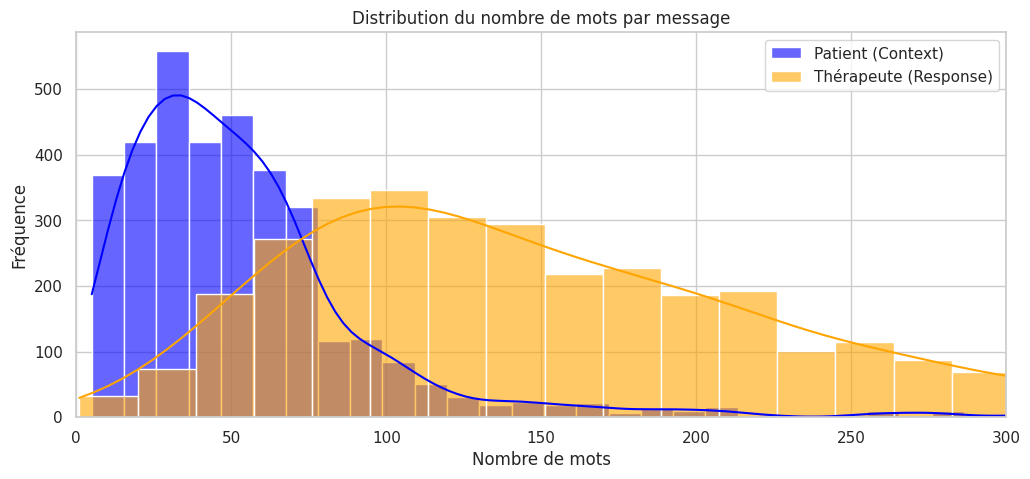

In [3]:
# Tableau statistique récapitulatif demandé
nb_echanges = len(df)
nb_patients_approx = df['Context'].nunique()
nb_therapeutes_approx = df['Response'].nunique()

print("--- TABLEAU STATISTIQUE RÉCAPITULATIF ---")
print(f"Nombre total d'échanges : {nb_echanges}")
print(f"Nombre de patients (Contextes uniques) : {nb_patients_approx}")
print(f"Nombre de thérapeutes (Réponses uniques) : {nb_therapeutes_approx}")
print(f"Moyenne d'échanges par thérapeute : {round(nb_echanges / nb_therapeutes_approx, 2)}")

# Ajoutons des colonnes pour la longueur des textes (nombre de mots)
df['Patient_Word_Count'] = df['Context'].apply(lambda x: len(str(x).split()))
df['Therapist_Word_Count'] = df['Response'].apply(lambda x: len(str(x).split()))

# Visualisation de la distribution de la longueur des textes
plt.figure(figsize=(12, 5))
sns.histplot(df['Patient_Word_Count'], color='blue', kde=True, label='Patient (Context)', alpha=0.6, bins=50)
sns.histplot(df['Therapist_Word_Count'], color='orange', kde=True, label='Thérapeute (Response)', alpha=0.6, bins=50)
plt.title('Distribution du nombre de mots par message')
plt.xlabel('Nombre de mots')
plt.ylabel('Fréquence')
plt.xlim(0, 300)
plt.legend()
plt.show()

### 3. Prétraitement du texte
Pour analyser les sujets, nous devons nettoyer le texte des patients (`Context`) : mise en minuscules, suppression de la ponctuation, et retrait des *stop words* (mots vides) anglais.

In [4]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Minuscules
    text = str(text).lower()
    # Suppression de la ponctuation et caractères spéciaux
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenization et suppression des stop words
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df['Context_Clean'] = df['Context'].apply(clean_text)
print("Aperçu du texte nettoyé :")
display(df[['Context', 'Context_Clean']].head(3))

Aperçu du texte nettoyé :


,Context,Context_Clean
0,I'm going through some things with my feelings...,going things feelings barely sleep nothing thi...
1,I'm going through some things with my feelings...,going things feelings barely sleep nothing thi...
2,I'm going through some things with my feelings...,going things feelings barely sleep nothing thi...


### Méthode 1 : Utilisation d'un lexique défini
Nous définissons une liste de mots-clés liés à la santé mentale et comptons leur fréquence d'apparition dans les propos des patients.

/tmp/ipykernel_12724/2010385033.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequence', y='Sujet', data=df_lexicon, palette='viridis')


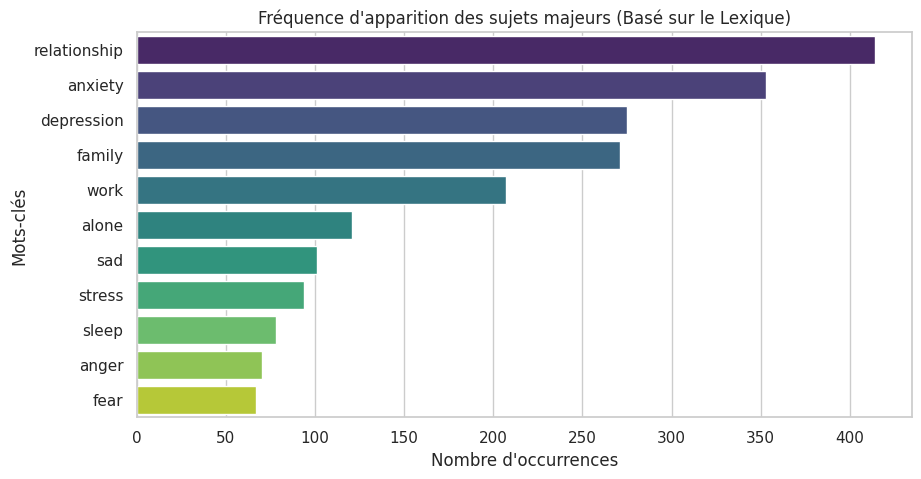

In [5]:
lexicon = ['stress', 'anxiety', 'depression', 'sleep', 'family', 'work', 'relationship', 'sad', 'anger', 'fear', 'alone']

# Comptage des occurrences
lexicon_counts = {word: 0 for word in lexicon}
for text in df['Context_Clean']:
    words = text.split()
    for word in lexicon:
        if word in words:
            lexicon_counts[word] += 1

# Transformation en DataFrame pour l'affichage
df_lexicon = pd.DataFrame(list(lexicon_counts.items()), columns=['Sujet', 'Frequence']).sort_values(by='Frequence', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Frequence', y='Sujet', data=df_lexicon, palette='viridis')
plt.title('Fréquence d\'apparition des sujets majeurs (Basé sur le Lexique)')
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('Mots-clés')
plt.show()

### Méthode 2 : Clustering avec vecteurs TF-IDF
Nous transformons les documents en vecteurs mathématiques basés sur l'importance des mots (TF-IDF), puis nous regroupons ces documents en 4 clusters (thèmes) avec l'algorithme KMeans.

In [6]:
num_clusters = 4

# Création de la matrice TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Context_Clean'])

# Application de KMeans
km = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
km.fit(tfidf_matrix)

# Récupération des mots les plus représentatifs pour chaque cluster
order_centroids = km.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()

print("--- Top mots par cluster (TF-IDF + KMeans) ---")
for i in range(num_clusters):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_words)}")

--- Top mots par cluster (TF-IDF + KMeans) ---
Cluster 0: know, want, dont, years, get, relationship, sex, told, time, love
Cluster 1: therapy, sessions, normal, still, counseling, cry, decide, client, counselor, process
Cluster 2: address, history, many, issues, counseling, ive, breast, insomniac, lifetime, happily
Cluster 3: feel, like, dont, people, really, know, always, get, anything, cant


### Méthode 3 : Clustering avec Word Embeddings (Word2Vec)
Nous entrainons un modèle Word2Vec sur notre corpus pour représenter les mots dans un espace vectoriel selon leur contexte. Ensuite, nous représentons chaque document par la moyenne de ses mots, et nous appliquons un clustering.

In [7]:
# Préparation des phrases pour Word2Vec
sentences = [text.split() for text in df['Context_Clean']]

# Entraînement du modèle Word2Vec
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4)

# Fonction pour créer le vecteur moyen d'un document
def document_vector(doc):
    words = [word for word in doc if word in w2v_model.wv.index_to_key]
    if len(words) == 0:
        return np.zeros(100)
    return np.mean(w2v_model.wv[words], axis=0)

X_w2v = np.array([document_vector(doc) for doc in sentences])

# Clustering KMeans sur les embeddings
km_w2v = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster_W2V'] = km_w2v.fit_predict(X_w2v)

print("Nombre de documents par cluster (Word2Vec) :")
print(df['Cluster_W2V'].value_counts())

print("\nExemple de mots similaires à 'anxiety' selon le modèle entrainé:")
try:
    print(w2v_model.wv.most_similar('anxiety', topn=5))
except KeyError:
    print("Le mot 'anxiety' n'est pas assez fréquent dans ce corpus.")

Nombre de documents par cluster (Word2Vec) :
Cluster_W2V
1    1787
0    1371
3     256
2      94
Name: count, dtype: int64

Exemple de mots similaires à 'anxiety' selon le modèle entrainé:
[('depression', 0.9941604733467102), ('beginning', 0.9867956638336182), ('low', 0.9707576036453247), ('misophonia', 0.9680996537208557), ('facing', 0.9616674780845642)]


### Méthode 4 : Modèle d'extraction de sujet (LDA)
Latent Dirichlet Allocation (LDA) est un modèle probabiliste classique pour extraire des *topics* (sujets) à partir d'une collection de textes.

In [9]:
num_topics = 4

# LDA requiert des fréquences brutes (CountVectorizer) plutôt que TF-IDF
tf_vectorizer = CountVectorizer(max_features=1000)
tf_matrix = tf_vectorizer.fit_transform(df['Context_Clean'])

# Création et entrainement du modèle LDA
lda = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda.fit(tf_matrix)

tf_feature_names = tf_vectorizer.get_feature_names_out()

print("--- Top mots par sujet (LDA) ---")
for topic_idx, topic in enumerate(lda.components_):
    top_words = [tf_feature_names[i] for i in topic.argsort()[:-10 - 1:-1]]
    print(f"Sujet {topic_idx}: {', '.join(top_words)}")

--- Top mots par sujet (LDA) ---
Sujet 0: dont, feel, know, cant, get, going, like, ive, think, want
Sujet 1: time, years, told, like, get, love, hes, back, never, got
Sujet 2: feel, dont, like, want, know, get, relationship, always, years, ive
Sujet 3: ive, issues, counseling, many, anxiety, depression, history, address, still, therapy


### Données supplémentaires

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

df = pd.read_csv('train.csv').dropna()

print("--- ANALYSE STATISTIQUE ---")
print("Nombre de mots moyens par patients :", round(df['Context'].apply(lambda x: len(str(x).split())).mean(), 2))
print("Nombre de mots moyens par thérapeutes :", round(df['Response'].apply(lambda x: len(str(x).split())).mean(), 2))

def get_ngrams(texts, ngram_range):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range, max_features=150000)
    matrix = vec.fit_transform(texts)
    
    freqs = [(word, matrix.getcol(idx).sum()) for word, idx in vec.vocabulary_.items()]
    freqs = sorted(freqs, key=lambda x: x[1], reverse=True)
    
    return len(vec.vocabulary_), [f"{w} (x{c})" for w, c in freqs[:3]]

uni_p_count, uni_p_top = get_ngrams(df['Context'], (1, 1))
uni_t_count, uni_t_top = get_ngrams(df['Response'], (1, 1))
_, uni_all_top = get_ngrams(df['Context'] + " " + df['Response'], (1, 1))

bi_p_count, _ = get_ngrams(df['Context'], (2, 2))
bi_t_count, _ = get_ngrams(df['Response'], (2, 2))

tri_p_count, _ = get_ngrams(df['Context'], (3, 3))
tri_t_count, _ = get_ngrams(df['Response'], (3, 3))

print("\n--- TOP 3 MOTS ---")
print("Top 3 mots patients :", ", ".join(uni_p_top))
print("Top 3 mots thérapeutes :", ", ".join(uni_t_top))
print("Trois mots utilisés en global :", ", ".join(uni_all_top))

print("\n--- ANALYSE LEXICALE ---")
print("Nombre d'unigram unique pour patients :", uni_p_count)
print("Nombre d'unigram unique pour thérapeutes :", uni_t_count)
print("Nombre de bigram unique pour patients :", bi_p_count)
print("Nombre de bigram unique pour thérapeutes :", bi_t_count)
print("Nombre de trigrams unique pour patients :", tri_p_count)
print("Nombre de trigrams unique pour thérapeutes :", tri_t_count)

def get_top_tfidf(texts):
    tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
    matrix = tfidf.fit_transform(texts)
    
    sum_scores = np.asarray(matrix.sum(axis=0)).ravel()
    
    top_indices = sum_scores.argsort()[::-1][:3]
    feature_names = tfidf.get_feature_names_out()
    
    return ", ".join([f"{feature_names[i]}" for i in top_indices])

print("\n--- SCORES TF-IDF ---")
print("Top 3 TF-IDF patients :", get_top_tfidf(df['Context']))
print("Top 3 TF-IDF thérapeutes :", get_top_tfidf(df['Response']))
print("Top 3 TF-IDF les deux :", get_top_tfidf(df['Context'] + " " + df['Response']))

--- ANALYSE STATISTIQUE ---
Nombre de mots moyens par patients : 55.2
Nombre de mots moyens par thérapeutes : 177.2

--- TOP 3 MOTS ---
Top 3 mots patients : feel (x1223), don (x1175), like (x1152)
Top 3 mots thérapeutes : feel (x2730), help (x2344), like (x2274)
Trois mots utilisés en global : feel (x3953), like (x3426), help (x2735)

--- ANALYSE LEXICALE ---
Nombre d'unigram unique pour patients : 3365
Nombre d'unigram unique pour thérapeutes : 14176
Nombre de bigram unique pour patients : 16109
Nombre de bigram unique pour thérapeutes : 109897
Nombre de trigrams unique pour patients : 17885
Nombre de trigrams unique pour thérapeutes : 138888


### Conclusion de l'Étape 1
Dans cette étape, nous avons exploré la structure du jeu de données (`train.csv`) et comparé plusieurs approches de NLP (Lexique, TF-IDF, Word Embeddings et LDA) pour extraire les sujets majeurs des préoccupations des patients.
Le document de restitution final devra comparer les avantages et les limites de ces 4 méthodes (ex: le lexique est précis mais limité à nos connaissances a priori, tandis que LDA découvre des sujets cachés mais peut manquer de sens humain immédiat).